# Analisis Numerik
## Perhitungan Volume Kedua Lambung Perahu Katamaran

**Nama:**  Eva Dwi Agista
**NPM:**  25083010017
**Kelas:**  A
**Mata Kuliah:** Analisis Numerik  
**Link Github:**  https://github.com/evaagista/Analisis-Numerik


## Tujuan

Menghitung volume kedua lambung katamaran dari gambar tampak atas dan tampak samping, tanpa memasukkan volume reserve buoyancy di ujung buritan dan haluan.

## Dasar Perhitungan

Lantai lambung datar tanpa keel, jadi setiap penampang melintang berbentuk persegi panjang:

$$A(x) = b(x)\cdot h(x)$$

dengan $b$ lebar lambung (tampak atas) dan $h$ tinggi lambung dari dek sampai dasar (tampak samping). Volume lambung adalah penjumlahan luas penampang sepanjang lambung:

$$V = \int_0^L A(x)\,dx$$

Karena $A(x)$ hanya diketahui di titik-titik hasil pengukuran gambar, integralnya dihitung secara numerik.

**Trapesium:** $V \approx \Delta x\left[\tfrac{A_0+A_n}{2} + A_1 + \dots + A_{n-1}\right]$

**Simpson 1/3:** $V \approx \tfrac{\Delta x}{3}\left[A_0 + 4(A_1+A_3+\dots+A_{n-1}) + 2(A_2+A_4+\dots+A_{n-2}) + A_n\right]$

Simpson 1/3 dipilih sebagai metode utama karena titik berjarak sama, jumlah interval genap (32), dan kurva $A(x)$ halus. Trapesium dipakai sebagai pembanding.

## Asumsi dan Satuan

- Satu dash-kosong = 5 + 5 cm = 10 cm.
- Lantai kapal datar (tanpa keel), tampak depan berbentuk persegi panjang.
- Reserve buoyancy tidak dihitung. Lambung dipotong pada garis sekat putus-putus di dekat buritan dan haluan.
- Semua ukuran diubah dari cm ke m (1 cm = 0,01 m), sehingga volume dinyatakan dalam m³.

## Input Data

Skala diperoleh dari dash pada garis grid hijau. Pada gambar yang dirender 300 dpi, satu dash-kosong (10 cm) membentang sekitar 24,9 px. Dengan skala itu:

- panjang lambung efektif (sekat buritan ke sekat haluan) = 1724 px,
- lambung dibagi 32 interval sama panjang, sehingga ada 33 titik pengukuran,
- lebar dibaca di tampak atas pada titik tengah garis tepi luar lambung, untuk lambung 1 dan lambung 2 secara terpisah,
- tinggi dibaca di tampak samping dari garis sheer (garis bawah dek) sampai garis dasar lambung.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
px_per_10cm = 24.9
panjang_px = 1724
n_interval = 32

cm_per_px = 10 / px_per_10cm
panjang = panjang_px * cm_per_px / 100
dx = panjang / n_interval
x = np.arange(n_interval + 1) * dx

lebar1_cm = np.array([73.2, 77.2, 80.8, 83.2, 85.6, 87.2, 88.0, 88.8, 89.2, 89.2, 89.2, 89.6, 89.2, 89.6, 89.2, 89.6, 89.6,
                      89.6, 89.6, 89.6, 89.6, 89.6, 89.2, 88.8, 88.0, 86.0, 84.0, 80.8, 77.6, 73.2, 67.6, 61.9, 54.7])
lebar2_cm = np.array([72.8, 77.2, 80.4, 83.2, 85.2, 87.2, 88.4, 89.2, 89.6, 89.6, 89.6, 89.6, 89.6, 89.6, 89.6, 89.6, 89.6,
                      89.6, 89.6, 89.6, 89.6, 89.6, 89.2, 88.8, 87.6, 86.0, 83.6, 80.8, 77.2, 72.8, 67.6, 61.5, 54.3])
tinggi_cm = np.array([73.3, 82.1, 89.4, 96.0, 101.4, 105.4, 105.4, 105.4, 105.4, 105.4, 105.2, 105.0, 104.8, 105.2, 105.0, 105.0, 105.0,
                      105.0, 105.0, 104.8, 104.6, 104.8, 104.6, 104.6, 104.6, 104.6, 104.6, 104.6, 104.6, 104.6, 104.4, 104.4, 104.2])

lebar1 = lebar1_cm / 100
lebar2 = lebar2_cm / 100
tinggi = tinggi_cm / 100

print(f"1 cm di gambar = {cm_per_px:.4f} cm sebenarnya per px")
print(f"Panjang lambung efektif = {panjang:.3f} m, dx = {dx:.4f} m")

1 cm di gambar = 0.4016 cm sebenarnya per px
Panjang lambung efektif = 6.924 m, dx = 0.2164 m


Skala 10 cm per 24,9 px berarti 1 px gambar mewakili sekitar 0,4 cm. Panjang lambung efektif sekitar 6,92 m dan dibagi 32 interval sehingga jarak antartitik sekitar 21,6 cm. Titik pertama berada di sekat buritan dan titik terakhir di sekat haluan, jadi bagian reserve buoyancy di luar kedua sekat tidak ikut terhitung.

## Validasi Data

In [3]:
assert len(x) == len(lebar1) == len(lebar2) == len(tinggi)
assert not np.isnan(np.concatenate([lebar1, lebar2, tinggi])).any()
assert np.all(np.diff(x) > 0)
assert np.allclose(np.diff(x), dx)
assert n_interval % 2 == 0

print(f"Jumlah titik x      : {len(x)}")
print(f"Jumlah data lebar   : {len(lebar1)} dan {len(lebar2)}")
print(f"Jumlah data tinggi  : {len(tinggi)}")
print(f"Jumlah interval     : {n_interval} (genap, syarat Simpson 1/3 terpenuhi)")
print(f"Jarak titik seragam : {np.allclose(np.diff(x), dx)}")

Jumlah titik x      : 33
Jumlah data lebar   : 33 dan 33
Jumlah data tinggi  : 33
Jumlah interval     : 32 (genap, syarat Simpson 1/3 terpenuhi)
Jarak titik seragam : True


Semua pengecekan lolos: panjang array sama, tidak ada nilai kosong, posisi berurutan, jarak antartitik seragam, dan jumlah interval genap. Artinya data layak dipakai untuk Simpson 1/3.

## Luas Penampang

In [4]:
luas1 = lebar1 * tinggi
luas2 = lebar2 * tinggi

tabel = pd.DataFrame({
    "Posisi (m)": x.round(3),
    "Lebar 1 (m)": lebar1,
    "Lebar 2 (m)": lebar2,
    "Tinggi (m)": tinggi,
    "Luas 1 (m²)": luas1.round(4),
    "Luas 2 (m²)": luas2.round(4),
})
tabel

,Posisi (m),Lebar 1 (m),Lebar 2 (m),Tinggi (m),Luas 1 (m²),Luas 2 (m²)
0,0.000,0.732,0.728,0.733,0.5366,0.5336
1,0.216,0.772,0.772,0.821,0.6338,0.6338
2,0.433,0.808,0.804,0.894,0.7224,0.7188
3,0.649,0.832,0.832,0.960,0.7987,0.7987
4,0.865,0.856,0.852,1.014,0.8680,0.8639
5,1.082,0.872,0.872,1.054,0.9191,0.9191
6,1.298,0.880,0.884,1.054,0.9275,0.9317
7,1.515,0.888,0.892,1.054,0.9360,0.9402
8,1.731,0.892,0.896,1.054,0.9402,0.9444
9,1.947,0.892,0.896,1.054,0.9402,0.9444


Luas penampang di bagian tengah lambung hampir konstan di sekitar 0,94 m² (0,896 m × 1,05 m). Di buritan luasnya sekitar 0,54 m² dan di haluan sekitar 0,57 m², karena lebar dan tinggi sama-sama mengecil di ujung. Perhatikan juga bahwa lebar lambung 1 dan lambung 2 nyaris sama di setiap titik.

## Perhitungan Volume Numerik

In [5]:
def trapezoidal_rule(x, y):
    total = 0
    for i in range(len(x) - 1):
        total += (x[i+1] - x[i]) * (y[i] + y[i+1]) / 2
    return total

def simpson_13(x, y):
    h = x[1] - x[0]
    return h / 3 * (y[0] + y[-1] + 4 * y[1:-1:2].sum() + 2 * y[2:-1:2].sum())

v_trap1 = trapezoidal_rule(x, luas1)
v_simp1 = simpson_13(x, luas1)

hitung_np = getattr(np, "trapezoid", None) or np.trapz
print(f"Trapesium manual : {v_trap1:.5f} m³")
print(f"Trapesium NumPy  : {hitung_np(luas1, x):.5f} m³")
print(f"Simpson 1/3      : {v_simp1:.5f} m³")

Trapesium manual : 6.02485 m³
Trapesium NumPy  : 6.02485 m³
Simpson 1/3      : 6.02967 m³


Trapesium menghubungkan titik-titik luas dengan garis lurus, sedangkan Simpson 1/3 memakai parabola pada setiap dua interval sehingga lebih teliti untuk kurva yang membulat. Trapesium manual dan fungsi NumPy memberi angka yang sama, yang menunjukkan fungsi manual benar. Simpson sedikit lebih besar karena menangkap lengkungan di ujung lambung.

## Detail Perhitungan Setiap Interval

In [6]:
A_awal = luas1[:-1]
A_akhir = luas1[1:]
A_rata = (A_awal + A_akhir) / 2
vol_interval = A_rata * np.diff(x)

detail = pd.DataFrame({
    "x awal (m)": x[:-1].round(3),
    "x akhir (m)": x[1:].round(3),
    "Δx (m)": np.diff(x).round(4),
    "A awal (m²)": A_awal.round(4),
    "A akhir (m²)": A_akhir.round(4),
    "A rata-rata (m²)": A_rata.round(4),
    "Volume interval (m³)": vol_interval.round(4),
})
print(f"Jumlah volume semua interval = {vol_interval.sum():.5f} m³")
detail

Jumlah volume semua interval = 6.02485 m³


,x awal (m),x akhir (m),Δx (m),A awal (m²),A akhir (m²),A rata-rata (m²),Volume interval (m³)
0,0.000,0.216,0.2164,0.5366,0.6338,0.5852,0.1266
1,0.216,0.433,0.2164,0.6338,0.7224,0.6781,0.1467
2,0.433,0.649,0.2164,0.7224,0.7987,0.7605,0.1646
3,0.649,0.865,0.2164,0.7987,0.8680,0.8334,0.1803
4,0.865,1.082,0.2164,0.8680,0.9191,0.8935,0.1933
5,1.082,1.298,0.2164,0.9191,0.9275,0.9233,0.1998
6,1.298,1.515,0.2164,0.9275,0.9360,0.9317,0.2016
7,1.515,1.731,0.2164,0.9360,0.9402,0.9381,0.2030
8,1.731,1.947,0.2164,0.9402,0.9402,0.9402,0.2034
9,1.947,2.164,0.2164,0.9402,0.9384,0.9393,0.2032


Tabel ini membuka proses Trapesium: tiap baris adalah satu potongan lambung dengan luas rata-rata kedua ujungnya dikali tebal potongan. Di bagian tengah, tiap potongan bervolume sekitar 0,20 m³, dan potongan di kedua ujung lebih kecil. Jumlah seluruh baris sama dengan hasil Trapesium sebelumnya, jadi tidak ada volume yang terhitung ganda.

## Volume Lambung 1

In [7]:
volume_lambung_1 = simpson_13(x, luas1)
print(f"Volume Lambung 1 = {volume_lambung_1:.4f} m³")

Volume Lambung 1 = 6.0297 m³


Angka ini adalah integrasi numerik luas penampang lambung 1 dari sekat buritan sampai sekat haluan dengan Simpson 1/3.

## Volume Lambung 2

Lambung 2 tidak langsung diasumsikan sama dengan lambung 1. Lebarnya dibaca sendiri dari tepi luar lambung bawah pada tampak atas, sedangkan tingginya memakai satu profil yang sama karena tampak samping hanya menunjukkan satu lambung. Dasar memakai tinggi yang sama adalah bahwa katamaran ini simetris, dengan dua lambung yang sejajar.

In [8]:
volume_lambung_2 = simpson_13(x, luas2)
selisih_lebar = np.abs(lebar1_cm - lebar2_cm).max()

print(f"Volume Lambung 2 = {volume_lambung_2:.4f} m³")
print(f"Selisih lebar terbesar antar lambung = {selisih_lebar:.1f} cm")

Volume Lambung 2 = 6.0293 m³
Selisih lebar terbesar antar lambung = 0.4 cm


Selisih lebar terbesar antara kedua lambung hanya sekitar 0,4 cm, yaitu di bawah ketelitian pembacaan gambar. Jadi kedua lambung memang identik berdasarkan data, dan volumenya hampir sama.

## Total Volume

In [9]:
volume_total = volume_lambung_1 + volume_lambung_2

print(f"Volume lambung 1 : {volume_lambung_1:.4f} m³")
print(f"Volume lambung 2 : {volume_lambung_2:.4f} m³")
print(f"Total volume     : {volume_total:.4f} m³ ({volume_total*1000:,.0f} liter)")

Volume lambung 1 : 6.0297 m³
Volume lambung 2 : 6.0293 m³
Total volume     : 12.0590 m³ (12,059 liter)


## Visualisasi

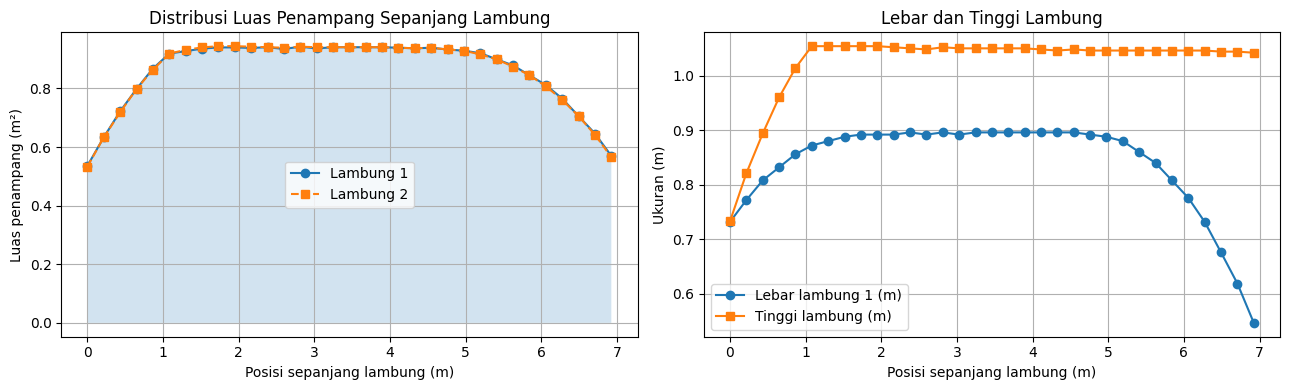

In [10]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))

a1.plot(x, luas1, "o-", label="Lambung 1")
a1.plot(x, luas2, "s--", label="Lambung 2")
a1.fill_between(x, luas1, alpha=0.2)
a1.set_title("Distribusi Luas Penampang Sepanjang Lambung")
a1.set_xlabel("Posisi sepanjang lambung (m)")
a1.set_ylabel("Luas penampang (m²)")
a1.grid(True)
a1.legend()

a2.plot(x, lebar1, "o-", label="Lebar lambung 1 (m)")
a2.plot(x, tinggi, "s-", label="Tinggi lambung (m)")
a2.set_title("Lebar dan Tinggi Lambung")
a2.set_xlabel("Posisi sepanjang lambung (m)")
a2.set_ylabel("Ukuran (m)")
a2.grid(True)
a2.legend()

plt.tight_layout()
plt.show()

Grafik kiri menunjukkan luas penampang naik dari buritan, datar di tengah, lalu turun ke haluan. Area di bawah kurva itulah yang dihitung sebagai volume. Grafik kanan menunjukkan penyebabnya: tinggi sudah penuh sekitar 1,05 m sejak seperempat awal lambung, sementara lebar baru menyempit tajam di bagian haluan.

## Validasi dan Perbandingan

In [11]:
selisih_metode = abs(v_simp1 - v_trap1)
persen_metode = selisih_metode / v_simp1 * 100
print(f"Simpson vs Trapesium (lambung 1): {selisih_metode:.5f} m³ ({persen_metode:.3f} %)")

def volume_total_variasi(skala=1.0, dlebar=0.0, dtinggi=0.0):
    a1 = (lebar1 + dlebar) * (tinggi + dtinggi)
    a2 = (lebar2 + dlebar) * (tinggi + dtinggi)
    return (simpson_13(x, a1) + simpson_13(x, a2)) * skala**3

for nama, v in [("lebar dan tinggi +1 cm", volume_total_variasi(dlebar=0.01, dtinggi=0.01)),
                ("lebar dan tinggi -1 cm", volume_total_variasi(dlebar=-0.01, dtinggi=-0.01)),
                ("skala +1 %", volume_total_variasi(skala=1.01)),
                ("skala -1 %", volume_total_variasi(skala=0.99))]:
    print(f"{nama:<24}: {v:.3f} m³ ({(v - volume_total) / volume_total * 100:+.1f} %)")

Simpson vs Trapesium (lambung 1): 0.00481 m³ (0.080 %)
lebar dan tinggi +1 cm  : 12.320 m³ (+2.2 %)
lebar dan tinggi -1 cm  : 11.801 m³ (-2.1 %)
skala +1 %              : 12.424 m³ (+3.0 %)
skala -1 %              : 11.701 m³ (-3.0 %)


Selisih Simpson dan Trapesium sangat kecil (sekitar 0,08%), tetapi itu hanya menunjukkan kedua metode konsisten, bukan bukti bahwa ukuran gambarnya benar, karena keduanya memakai data yang sama.

Uji sensitivitas lebih berguna. Kesalahan baca 1 cm pada lebar dan tinggi mengubah total volume sekitar 2%, dan kesalahan skala 1% mengubahnya sekitar 3% karena volume sebanding dengan pangkat tiga skala. 

## Kesimpulan

Volume kedua lambung katamaran dihitung dengan integrasi numerik Simpson 1/3 atas $V=\int A(x)\,dx$, dengan $A = b \times h$ karena lantai datar dan penampang berbentuk persegi panjang. Lambung dibagi 32 interval sama panjang sepanjang sekitar 6,92 m dari sekat buritan sampai sekat haluan. Hasilnya:

- Volume lambung 1 ≈ **6,030 m³**
- Volume lambung 2 ≈ **6,029 m³**
- Total volume ≈ **12,059 m³** (sekitar 12.059 liter)

Metode Trapesium memberi hasil yang hanya berbeda sekitar 0,08%. Asumsi yang dipakai: 1 dash-kosong = 10 cm, lantai datar tanpa keel, reserve buoyancy tidak dihitung, dan ukuran dibaca dari gambar sehingga ketelitiannya sekitar ±1 cm.